2026-03-29 23:11:10 | INFO | ai-vpn-firewall | Raw USBVPN dir expected at: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\raw\usbvpn
2026-03-29 23:11:10 | INFO | ai-vpn-firewall | Processed USBVPN Parquet will be saved to: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\processed\usbvpn\flows.parquet
2026-03-29 23:11:10 | INFO | ai-vpn-firewall | Loaded features config: min_packets=3, eps=1e-06
2026-03-29 23:11:10 | INFO | ai-vpn-firewall | Loading JSONs from: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\raw\usbvpn
2026-03-29 23:11:10 | INFO | ai-vpn-firewall | Found 35 JSON files in C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\raw\usbvpn
2026-03-29 23:28:28 | INFO | ai-vpn-firewall | Extracted 58977 flows from raw data.
2026-03-29 23:28:29 | INFO | ai-vpn-firewall | Adapted USBVPN shape: (58977, 38)
  flow_id        capture_id source_capture_id source_file dataset  label  \
0  mail_0  mail__chunk_0000              mail   mail.json  usbvpn      0   
1  mail_1  ma

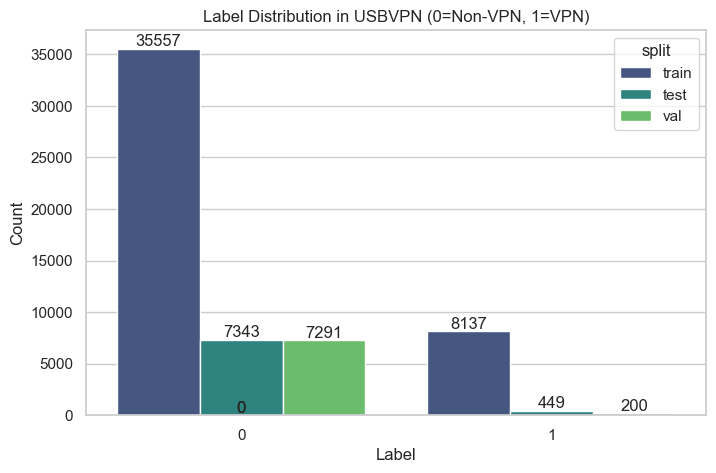

2026-03-29 23:28:30 | INFO | ai-vpn-firewall | Loaded prepared ISCX features: C:\Users\scoti\PycharmProjects\ai-vpn-firewall\data\processed\iscx\features.parquet
2026-03-29 23:28:30 | ERROR | ai-vpn-firewall | Error loading existing prepared features for comparison: Cannot derive compact features, missing base columns: ['sz_all_mean', 'sz_all_std', 'sz_all_median', 'sz_all_p25', 'sz_all_p75']
Cannot run Dataset Detector: existing prepared features.parquet not found.
2026-03-29 23:28:30 | INFO | ai-vpn-firewall | Running Schema Alignment Test...
2026-03-29 23:28:30 | WARNING | ai-vpn-firewall | Could not load existing prepared features to verify schema alignment.

--- USBVPN Metadata Audit ---
source_capture_id: OK
source_file: OK
capture_id: OK
split: OK
label: OK

Top source files by flow count:
source_capture_id
non_streaming    54079
streaming         4631
mail               107
meet                87
ssh                 73
Name: count, dtype: int64

Cross-tab: source file by split


In [1]:
%matplotlib inline

import json
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

from src.utils.paths import load_paths
from src.utils.logging import setup_logger
from src.features.extract import load_feature_config

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

paths = load_paths()
paths.ensure_dirs()
logger = setup_logger(level="INFO")

USBVPN_RAW_DIR = paths.data_raw_dir / "usbvpn"
PROCESSED_USBVPN_DIR = paths.data_processed_dir / "usbvpn"
PROCESSED_USBVPN_DIR.mkdir(parents=True, exist_ok=True)
FLOWS_PARQUET_PATH = PROCESSED_USBVPN_DIR / "flows.parquet"

logger.info(f"Raw USBVPN dir expected at: {USBVPN_RAW_DIR}")
logger.info(f"Processed USBVPN Parquet will be saved to: {FLOWS_PARQUET_PATH}")

# ---------------------------------------------------------------------
# Compact features: keep names exactly as in your pipeline
# ---------------------------------------------------------------------
COMPACT_FEATURES = [
    "sz_coef_variation",
    "sz_p25_median_ratio",
    "sz_p75_median_ratio",
    "sz_iqr_norm_median",
    "dispersion_symmetry",
    "direction_balance_bytes",
    "direction_balance_packets",
]

features_yaml = paths.configs_dir / "features.yaml"
cfg = load_feature_config(features_yaml)
EPS = float(cfg.eps)
MIN_PACKETS = int(cfg.min_packets)

logger.info(f"Loaded features config: min_packets={MIN_PACKETS}, eps={EPS}")


def _safe_div(a: float, b: float, eps: float) -> float:
    return float(a) / (float(b) + eps)


def _bounded_balance(pos: float, neg: float, eps: float) -> float:
    """
    Bounded directional balance in [-1, 1].
    This avoids exploding values when one side is zero.
    """
    pos = float(pos)
    neg = float(neg)
    return (pos - neg) / (pos + neg + eps)


def _finalize_numeric(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
            out[c] = out[c].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return out


def _calculate_flow_stats_from_packets(packets: list, eps: float) -> dict:
    """
    Build base flow stats + compact features from USBVPN JSON packets.
    """
    if not packets:
        return {}

    sizes_fwd = []
    sizes_bwd = []
    times_all = []

    time_fmt = "%Y-%m-%d %H:%M:%S.%f"

    for p in packets:
        try:
            b = int(p.get("bytes", 0))

            if b > 0:
                sizes_fwd.append(b)
            elif b < 0:
                sizes_bwd.append(abs(b))

            ts_str = p.get("timestamp_start")
            if ts_str:
                try:
                    ts = datetime.strptime(ts_str, time_fmt).timestamp()
                    times_all.append(ts)
                except ValueError:
                    pass
        except Exception:
            continue

    sizes_all = sizes_fwd + sizes_bwd
    if len(sizes_all) == 0:
        return {}

    times_all.sort()
    iats_all = np.diff(times_all) if len(times_all) > 1 else np.array([])

    def calc_stats(arr):
        if len(arr) == 0:
            return 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
        arr = np.asarray(arr, dtype=float)
        return (
            float(np.mean(arr)),
            float(np.std(arr, ddof=0)) if len(arr) > 1 else 0.0,
            float(np.min(arr)),
            float(np.max(arr)),
            float(np.median(arr)),
            float(np.percentile(arr, 25)),
            float(np.percentile(arr, 75)),
        )

    # size stats
    sz_all_mean, sz_all_std, _, _, sz_all_median, sz_all_p25, sz_all_p75 = calc_stats(sizes_all)
    sz_fwd_mean, sz_fwd_std, _, _, _, _, _ = calc_stats(sizes_fwd)
    sz_bwd_mean, sz_bwd_std, _, _, _, _, _ = calc_stats(sizes_bwd)

    # iat stats
    iat_all_mean, iat_all_std, _, _, iat_all_median, iat_all_p25, iat_all_p75 = calc_stats(iats_all)

    # approximate directional IAT stats because JSON format does not preserve them separately
    iat_fwd_mean = iat_all_mean
    iat_bwd_mean = iat_all_mean
    iat_fwd_std = iat_all_std
    iat_bwd_std = iat_all_std

    bytes_up = float(np.sum(sizes_fwd)) if len(sizes_fwd) else 0.0
    bytes_down = float(np.sum(sizes_bwd)) if len(sizes_bwd) else 0.0
    packets_up = float(len(sizes_fwd))
    packets_down = float(len(sizes_bwd))

    sz_iqr = float(sz_all_p75 - sz_all_p25)
    lower_spread = float(sz_all_median - sz_all_p25)
    upper_spread = float(sz_all_p75 - sz_all_median)

    out = {
        # base feature family
        "sz_all_mean": float(sz_all_mean),
        "sz_all_std": float(sz_all_std),
        "sz_all_median": float(sz_all_median),
        "sz_all_p25": float(sz_all_p25),
        "sz_all_p75": float(sz_all_p75),

        "sz_mean_max": float(max(sz_fwd_mean, sz_bwd_mean)),
        "sz_mean_min": float(min(sz_fwd_mean, sz_bwd_mean)),
        "sz_std_max": float(max(sz_fwd_std, sz_bwd_std)),
        "sz_std_min": float(min(sz_fwd_std, sz_bwd_std)),

        "iat_all_mean": float(iat_all_mean),
        "iat_all_std": float(iat_all_std),
        "iat_all_median": float(iat_all_median),
        "iat_all_p25": float(iat_all_p25),
        "iat_all_p75": float(iat_all_p75),

        "iat_mean_max": float(max(iat_fwd_mean, iat_bwd_mean)),
        "iat_mean_min": float(min(iat_fwd_mean, iat_bwd_mean)),
        "iat_std_max": float(max(iat_fwd_std, iat_bwd_std)),
        "iat_std_min": float(min(iat_fwd_std, iat_bwd_std)),

        "tot_pkt": int(len(sizes_all)),

        # raw directional support cols
        "bytes_up": float(bytes_up),
        "bytes_down": float(bytes_down),
        "packets_up": float(packets_up),
        "packets_down": float(packets_down),

        # compact features required by pipeline
        "sz_coef_variation": _safe_div(sz_all_std, sz_all_mean, eps) if sz_all_mean > 0 else 0.0,
        "sz_p25_median_ratio": _safe_div(sz_all_p25, abs(sz_all_median), eps),
        "sz_p75_median_ratio": _safe_div(sz_all_p75, abs(sz_all_median), eps),
        "sz_iqr_norm_median": _safe_div(sz_iqr, abs(sz_all_median), eps),
        "dispersion_symmetry": _safe_div(upper_spread, abs(lower_spread), eps),

        # fixed: bounded, no giant explosions
        "direction_balance_bytes": _bounded_balance(bytes_up, bytes_down, eps),
        "direction_balance_packets": _bounded_balance(packets_up, packets_down, eps),
    }

    return out


def adapt_usbvpn_to_pipeline(raw_dir: Path, eps: float, min_packets: int) -> pd.DataFrame:
    """
    Loads USBVPN JSON files and adapts them to the schema expected by the compact pipeline.
    """
    logger.info(f"Loading JSONs from: {raw_dir}")

    if not raw_dir.exists():
        raise FileNotFoundError(f"USBVPN raw dir not found: {raw_dir}")

    json_files = list(raw_dir.rglob("*.json"))
    logger.info(f"Found {len(json_files)} JSON files in {raw_dir}")

    USBVPN_SUBCAPTURE_SIZE = 100

    all_records = []
    for jf in json_files:
        try:
            with open(jf, "r", encoding="utf-8") as f:
                data = json.load(f)

            if not isinstance(data, list):
                logger.warning(f"Unexpected JSON structure in {jf}. Expected list of flows.")
                continue

            for i, flow_data in enumerate(data):
                packets = flow_data.get("x_packets", [])
                stats = _calculate_flow_stats_from_packets(packets, eps=eps)
                if not stats:
                    continue

                subcapture_id = f"{jf.stem}__chunk_{i // USBVPN_SUBCAPTURE_SIZE:04d}"

                record = {
                    "flow_id": f"{jf.stem}_{i}",
                    "capture_id": subcapture_id,
                    "source_capture_id": jf.stem,
                    "source_file": jf.name,
                    "dataset": "usbvpn",
                }

                jf_lower = str(jf).lower()
                if "nonvpn" in jf_lower or "non-vpn" in jf_lower:
                    record["label"] = 0
                elif "vpn" in jf_lower:
                    record["label"] = 1
                else:
                    record["label"] = 0

                record.update(stats)
                all_records.append(record)

        except Exception as e:
            logger.error(f"Error parsing JSON {jf}: {e}")

    if not all_records:
        raise ValueError(f"No valid records extracted from JSON files in {raw_dir}")

    df_out = pd.DataFrame(all_records)
    logger.info(f"Extracted {len(df_out)} flows from raw data.")

    df_out["q_packet_count"] = pd.to_numeric(df_out.get("tot_pkt", 0), errors="coerce").fillna(0).astype(float)
    df_out["q_min_packets_ok"] = (df_out["q_packet_count"] >= float(min_packets)).astype(float)

    numeric_cols = [
        "sz_all_mean", "sz_all_std", "sz_all_median", "sz_all_p25", "sz_all_p75",
        "sz_mean_max", "sz_mean_min", "sz_std_max", "sz_std_min",
        "iat_all_mean", "iat_all_std", "iat_all_median", "iat_all_p25", "iat_all_p75",
        "iat_mean_max", "iat_mean_min", "iat_std_max", "iat_std_min",
        "tot_pkt", "bytes_up", "bytes_down", "packets_up", "packets_down",
        "q_packet_count", "q_min_packets_ok",
    ] + COMPACT_FEATURES

    df_out = _finalize_numeric(df_out, numeric_cols)

    required_cols = [
        "flow_id", "capture_id", "source_capture_id", "source_file", "dataset", "label",
        "q_packet_count", "q_min_packets_ok",
        "sz_all_mean", "sz_all_std", "sz_all_median", "sz_all_p25", "sz_all_p75",
        "sz_mean_max", "sz_mean_min", "sz_std_max", "sz_std_min",
        "iat_all_mean", "iat_all_std", "iat_all_median", "iat_all_p25", "iat_all_p75",
        "iat_mean_max", "iat_mean_min", "iat_std_max", "iat_std_min",
    ] + COMPACT_FEATURES

    missing_required = [c for c in required_cols if c not in df_out.columns]
    if missing_required:
        raise ValueError(f"USBVPN adapter missing required columns: {missing_required}")

    return df_out


def add_compact_features_from_existing_columns(df: pd.DataFrame, eps: float) -> pd.DataFrame:
    """
    Make sure already prepared VNAT/ISCX features also contain the same compact columns as USBVPN.
    This function assumes you load prepared feature tables, not raw flows.
    """
    out = df.copy()

    required_for_compact = [
        "sz_all_mean", "sz_all_std", "sz_all_median", "sz_all_p25", "sz_all_p75"
    ]
    missing = [c for c in required_for_compact if c not in out.columns]
    if missing:
        raise ValueError(f"Cannot derive compact features, missing base columns: {missing}")

    if "bytes_up" not in out.columns:
        out["bytes_up"] = 0.0
    if "bytes_down" not in out.columns:
        out["bytes_down"] = 0.0
    if "packets_up" not in out.columns:
        out["packets_up"] = 0.0
    if "packets_down" not in out.columns:
        out["packets_down"] = 0.0

    out["sz_coef_variation"] = out["sz_all_std"] / (out["sz_all_mean"].abs() + eps)
    out["sz_p25_median_ratio"] = out["sz_all_p25"] / (out["sz_all_median"].abs() + eps)
    out["sz_p75_median_ratio"] = out["sz_all_p75"] / (out["sz_all_median"].abs() + eps)
    out["sz_iqr_norm_median"] = (out["sz_all_p75"] - out["sz_all_p25"]) / (out["sz_all_median"].abs() + eps)
    out["dispersion_symmetry"] = (out["sz_all_p75"] - out["sz_all_median"]) / (
        (out["sz_all_median"] - out["sz_all_p25"]).abs() + eps
    )

    # fixed: bounded, no explosions
    out["direction_balance_bytes"] = (out["bytes_up"] - out["bytes_down"]) / (
        out["bytes_up"].abs() + out["bytes_down"].abs() + eps
    )
    out["direction_balance_packets"] = (out["packets_up"] - out["packets_down"]) / (
        out["packets_up"].abs() + out["packets_down"].abs() + eps
    )

    out = _finalize_numeric(out, COMPACT_FEATURES + ["bytes_up", "bytes_down", "packets_up", "packets_down"])
    return out


df_usbvpn = adapt_usbvpn_to_pipeline(USBVPN_RAW_DIR, eps=EPS, min_packets=MIN_PACKETS)
logger.info(f"Adapted USBVPN shape: {df_usbvpn.shape}")
print(df_usbvpn.head())


def group_based_split(
    df: pd.DataFrame,
    group_col: str = "capture_id",
    label_col: str = "label",
    random_state: int = 45,
    train_frac: float = 0.7,
    val_frac: float = 0.15,
    min_vpn_flows_val: int = 200,
    min_vpn_flows_test: int = 200,
) -> pd.DataFrame:
    df = df.copy()
    rng = np.random.default_rng(random_state)

    meta = df.groupby(group_col).agg({
        label_col: "max",
        "source_capture_id": "first",
        "flow_id": "count",
    }).rename(columns={"flow_id": "n_flows"}).reset_index()

    zero_shot_protocols = ["ssh", "wireguard"]
    is_zero_shot = meta["source_capture_id"].str.lower().str.contains("|".join(zero_shot_protocols), na=False)
    meta_zero_shot = meta[is_zero_shot].copy()
    meta_regular = meta[~is_zero_shot].copy()

    vpn_caps = meta_regular[meta_regular[label_col] == 1].copy()
    non_vpn_caps = meta_regular[meta_regular[label_col] == 0].copy()

    vpn_caps = vpn_caps.sample(frac=1, random_state=random_state)
    vpn_caps_list = list(vpn_caps.itertuples(index=False))

    vpn_test_caps, vpn_val_caps = [], []
    test_flows, val_flows = 0, 0

    while test_flows < min_vpn_flows_test and vpn_caps_list:
        cap = vpn_caps_list.pop(0)
        vpn_test_caps.append(cap.capture_id)
        test_flows += cap.n_flows

    while val_flows < min_vpn_flows_val and vpn_caps_list:
        cap = vpn_caps_list.pop(0)
        vpn_val_caps.append(cap.capture_id)
        val_flows += cap.n_flows

    vpn_train_caps = [cap.capture_id for cap in vpn_caps_list]

    non_vpn_list = non_vpn_caps[group_col].tolist()
    rng.shuffle(non_vpn_list)

    n = len(non_vpn_list)
    n_train = int(round(train_frac * n))
    n_val = int(round(val_frac * n))

    non_vpn_train = non_vpn_list[:n_train]
    non_vpn_val = non_vpn_list[n_train:n_train + n_val]
    non_vpn_test = non_vpn_list[n_train + n_val:]

    train_caps = set(vpn_train_caps + non_vpn_train)
    val_caps = set(vpn_val_caps + non_vpn_val)
    test_caps = set(vpn_test_caps + non_vpn_test + meta_zero_shot[group_col].tolist())

    df["split"] = "train"
    df.loc[df[group_col].isin(val_caps), "split"] = "val"
    df.loc[df[group_col].isin(test_caps), "split"] = "test"

    return df


df_usbvpn_split = group_based_split(df_usbvpn)

print("\n--- Leakage Verification ---")
train_caps_verify = set(df_usbvpn_split[df_usbvpn_split["split"] == "train"]["capture_id"])
val_caps_verify = set(df_usbvpn_split[df_usbvpn_split["split"] == "val"]["capture_id"])
test_caps_verify = set(df_usbvpn_split[df_usbvpn_split["split"] == "test"]["capture_id"])

print(f"Train/Test Overlap: {train_caps_verify & test_caps_verify}")
print(f"Train/Val Overlap: {train_caps_verify & val_caps_verify}")
print(f"Val/Test Overlap: {val_caps_verify & test_caps_verify}")

print("\n--- Split Distribution Summary ---")
summary = []
for s in ["train", "val", "test"]:
    sub = df_usbvpn_split[df_usbvpn_split["split"] == s]
    summary.append({
        "Split": s,
        "Unique synthetic groups": sub["capture_id"].nunique(),
        "Unique source files": sub["source_capture_id"].nunique() if "source_capture_id" in sub.columns else np.nan,
        "Total Flows": len(sub),
        "VPN %": f"{100 * sub['label'].mean():.1f}%" if len(sub) else "0.0%",
    })

print(pd.DataFrame(summary).to_string(index=False))

if df_usbvpn_split.groupby("split")["capture_id"].nunique().min() < 3:
    raise ValueError(
        "USBVPN split still has too few synthetic capture groups. "
        "Reduce USBVPN_SUBCAPTURE_SIZE."
    )

df_usbvpn_split.to_parquet(FLOWS_PARQUET_PATH, index=False)
logger.info(f"Saved prepared USBVPN flows to {FLOWS_PARQUET_PATH}")

# Label distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df_usbvpn_split, x="label", hue="split", palette="viridis")
plt.title("Label Distribution in USBVPN (0=Non-VPN, 1=VPN)")
plt.xlabel("Label")
plt.ylabel("Count")
for p in ax.patches:
    height = p.get_height()
    if pd.notna(height):
        ax.annotate(
            f"{int(height)}",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="center",
            xytext=(0, 5),
            textcoords="offset points",
        )
plt.show()

COMPARE_EXISTING = False
df_existing = None

try:
    # FIX: load prepared feature tables, not raw flows
    iscx_feat_path = paths.data_processed_dir / "iscx" / "features.parquet"
    vnat_feat_path = paths.data_processed_dir / "vnat" / "features.parquet"

    dfs_to_concat = []

    if iscx_feat_path.exists():
        feat_iscx = pd.read_parquet(iscx_feat_path).copy()
        feat_iscx["dataset"] = "iscx"
        feat_iscx = add_compact_features_from_existing_columns(feat_iscx, eps=EPS)
        dfs_to_concat.append(feat_iscx)
        logger.info(f"Loaded prepared ISCX features: {iscx_feat_path}")
    else:
        logger.warning(f"ISCX features not found at {iscx_feat_path}")

    if vnat_feat_path.exists():
        feat_vnat = pd.read_parquet(vnat_feat_path).copy()
        feat_vnat["dataset"] = "vnat"
        feat_vnat = add_compact_features_from_existing_columns(feat_vnat, eps=EPS)
        dfs_to_concat.append(feat_vnat)
        logger.info(f"Loaded prepared VNAT features: {vnat_feat_path}")
    else:
        logger.warning(f"VNAT features not found at {vnat_feat_path}")

    if dfs_to_concat:
        df_existing = pd.concat(dfs_to_concat, ignore_index=True)
        logger.info(f"Combined existing prepared features shape: {df_existing.shape}")

        overlap_cols = ["dataset", "sz_all_mean", "iat_all_mean"]

        df_vis = pd.concat([
            df_existing[overlap_cols].dropna(),
            df_usbvpn_split[overlap_cols].dropna(),
        ], ignore_index=True)

        fig, axes = plt.subplots(1, 2, figsize=(16, 6))

        with warnings.catch_warnings():
            warnings.simplefilter("ignore", UserWarning)
            sns.kdeplot(
                data=df_vis,
                x="sz_all_mean",
                hue="dataset",
                ax=axes[0],
                log_scale=True,
                common_norm=False,
                fill=True,
                alpha=0.3,
            )
            axes[0].set_title("Distribution of sz_all_mean (Log Scale)")

            sns.kdeplot(
                data=df_vis,
                x="iat_all_mean",
                hue="dataset",
                ax=axes[1],
                log_scale=True,
                common_norm=False,
                fill=True,
                alpha=0.3,
            )
            axes[1].set_title("Distribution of iat_all_mean (Log Scale)")

        plt.tight_layout()
        plt.show()

        COMPARE_EXISTING = True
    else:
        logger.warning("No existing prepared feature tables found. Skipping comparison.")
        COMPARE_EXISTING = False

except Exception as e:
    logger.error(f"Error loading existing prepared features for comparison: {e}")
    COMPARE_EXISTING = False

if COMPARE_EXISTING and df_existing is not None:
    feature_cols = [
        "sz_all_mean", "sz_all_std", "sz_all_p25",
        "sz_all_median", "sz_all_p75", "sz_mean_max",
        "sz_mean_min", "sz_std_max", "sz_std_min",
    ]

    df_existing = df_existing.copy()
    df_usbvpn_split = df_usbvpn_split.copy()
    df_existing["is_usbvpn"] = 0
    df_usbvpn_split["is_usbvpn"] = 1

    if "split" in df_existing.columns:
        train_existing = df_existing[df_existing["split"] == "train"]
        test_existing = df_existing[df_existing["split"] == "test"]
    else:
        train_existing, test_existing = train_test_split(df_existing, test_size=0.3, random_state=42)

    train_usbvpn = df_usbvpn_split[df_usbvpn_split["split"] == "train"]
    test_usbvpn = df_usbvpn_split[df_usbvpn_split["split"] == "test"]

    df_det_train = pd.concat([train_existing, train_usbvpn], ignore_index=True)
    df_det_test = pd.concat([test_existing, test_usbvpn], ignore_index=True)

    missing_feats = [c for c in feature_cols if c not in df_det_train.columns]
    if missing_feats:
        logger.warning(f"Missing features in existing data: {missing_feats}. Dropping from detector.")
        feature_cols = [c for c in feature_cols if c in df_det_train.columns]

    df_det_train = df_det_train.dropna(subset=feature_cols)
    df_det_test = df_det_test.dropna(subset=feature_cols)

    X_tr = df_det_train[feature_cols].to_numpy()
    y_tr = df_det_train["is_usbvpn"].to_numpy()

    X_te = df_det_test[feature_cols].to_numpy()
    y_te = df_det_test["is_usbvpn"].to_numpy()

    logger.info("Training Dataset Detector (USBVPN vs Others)...")
    clf_detector = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        eval_metric="auc",
        random_state=42,
        n_jobs=4,
    )

    clf_detector.fit(X_tr, y_tr)

    p_te = clf_detector.predict_proba(X_te)[:, 1]
    y_pred = (p_te > 0.5).astype(int)

    auc = roc_auc_score(y_te, p_te)

    print("\nDataset Detector Results (Target=USBVPN):")
    print(f"Test AUC: {auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_te, y_pred, target_names=["ISCX/VNAT", "USBVPN"]))

    imp = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": clf_detector.feature_importances_,
    }).sort_values("Importance", ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=imp, x="Importance", y="Feature", hue="Feature", palette="rocket", legend=False)
    plt.title("Features Most Indicative of the USBVPN Dataset")
    plt.show()

    if auc > 0.95:
        logger.warning("HIGH DOMAIN SHIFT DETECTED. The model can easily distinguish USBVPN from ISCX/VNAT.")
        logger.warning("Consider feature pruning or domain adaptation techniques in the main pipeline.")
    else:
        logger.info("Moderate domain shift. The datasets have overlapping feature spaces.")
else:
    print("Cannot run Dataset Detector: existing prepared features.parquet not found.")

logger.info("Running Schema Alignment Test...")

usbvpn_test_df = pd.read_parquet(FLOWS_PARQUET_PATH)
usbvpn_cols = set(usbvpn_test_df.columns)

if df_existing is not None:
    existing_cols = set(df_existing.columns)

    in_usbvpn_not_existing = usbvpn_cols - existing_cols
    in_existing_not_usbvpn = existing_cols - usbvpn_cols

    CRITICAL_FEATURES = {
        "sz_all_mean", "sz_all_std", "sz_mean_max", "sz_mean_min", "sz_std_max", "sz_std_min",
        "iat_all_mean", "iat_all_std", "iat_mean_max", "iat_mean_min", "iat_std_max", "iat_std_min",
        "q_packet_count", "q_min_packets_ok",
        "sz_coef_variation", "sz_p25_median_ratio", "sz_p75_median_ratio",
        "sz_iqr_norm_median", "dispersion_symmetry", "direction_balance_bytes",
        "direction_balance_packets",
    }

    missing_critical_in_usbvpn = CRITICAL_FEATURES - usbvpn_cols
    missing_critical_in_existing = CRITICAL_FEATURES - existing_cols

    feature_mismatch_usbvpn = [
        c for c in in_usbvpn_not_existing
        if c.startswith("sz_") or c.startswith("iat_") or c.startswith("h_") or c.startswith("q_")
    ]
    feature_mismatch_existing = [
        c for c in in_existing_not_usbvpn
        if c.startswith("sz_") or c.startswith("iat_") or c.startswith("h_") or c.startswith("q_")
    ]

    print("\n--- Detailed Column Analysis ---")
    print(f"USBVPN columns: {len(usbvpn_cols)}")
    print(f"Existing data columns: {len(existing_cols)}")
    print(f"Overlapping columns: {len(usbvpn_cols & existing_cols)}")
    print(f"\nFeatures ONLY in USBVPN: {feature_mismatch_usbvpn}")
    print(f"Features ONLY in existing data: {feature_mismatch_existing}")

    if missing_critical_in_usbvpn:
        logger.error(f"CRITICAL FEATURES MISSING in USBVPN: {missing_critical_in_usbvpn}")
        raise ValueError(f"USBVPN missing critical features: {missing_critical_in_usbvpn}")

    if missing_critical_in_existing:
        logger.error(f"CRITICAL FEATURES MISSING in existing data: {missing_critical_in_existing}")
        logger.warning("Existing prepared features may not be fully aligned yet.")

    if feature_mismatch_usbvpn or feature_mismatch_existing:
        logger.info("Non-critical feature differences detected (OK):")
        logger.info(f"  - USBVPN has extra: {feature_mismatch_usbvpn}")
        logger.info(f"  - Existing has extra: {feature_mismatch_existing}")

    logger.info("SUCCESS: USBVPN contains all critical features for integration.")
    print("\n✓ Aligned Critical Feature Schema Check Passed!")
    print(f"  Total overlapping columns: {len(usbvpn_cols.intersection(existing_cols))}")
else:
    logger.warning("Could not load existing prepared features to verify schema alignment.")

print("\n--- USBVPN Metadata Audit ---")
required_meta = ["source_capture_id", "source_file", "capture_id", "split", "label"]
for c in required_meta:
    print(f"{c}: {'OK' if c in df_usbvpn_split.columns else 'MISSING'}")

print("\nTop source files by flow count:")
print(df_usbvpn_split["source_capture_id"].value_counts().head(20))

print("\nCross-tab: source file by split")
print(pd.crosstab(df_usbvpn_split["source_capture_id"], df_usbvpn_split["split"]))